# Batch Document Extraction with InternVL3

This notebook demonstrates how to perform batch document extraction using the InternVL3 model. 
It includes steps for: 
 * loading documents
 * detecting document types
 * extracting relevant information
 * generating reports.

## 1. Imports

In [1]:
# Enable autoreload for module changes
%load_ext autoreload
%autoreload 2

# Standard library imports
import warnings
from datetime import datetime
from pathlib import Path

# Third-party imports
import numpy as np
import pandas as pd
from IPython.display import display
from rich import print as rprint
from rich.console import Console

# Project-specific imports
from common.batch_analytics import BatchAnalytics
from common.batch_processor import BatchDocumentProcessor
from common.batch_reporting import BatchReporter
from common.batch_visualizations import BatchVisualizer
from common.evaluation_metrics import load_ground_truth
from common.extraction_parser import discover_images
from common.gpu_optimization import emergency_cleanup
from common.internvl3_model_loader import load_internvl3_model
from models.document_aware_internvl3_processor import (
    DocumentAwareInternVL3HybridProcessor,
)

print("✅ All imports loaded successfully")
print("✅ InternVL3 Hybrid Processor imported successfully") 
print("✅ Proven batch processing modules imported successfully")
warnings.filterwarnings('ignore')

✅ All imports loaded successfully
✅ InternVL3 Hybrid Processor imported successfully
✅ Proven batch processing modules imported successfully


## 2. Pre-emptive Memory Cleanup

**CRITICAL for V100**: Run this cell first to prevent OOM errors when switching between models.

In [2]:
# Pre-emptive V100 Memory Cleanup - Run FIRST to prevent OOM errors
rprint("[bold red]🧹 PRE-EMPTIVE V100 MEMORY CLEANUP[/bold red]")
rprint("[yellow]Clearing any existing model caches before loading...[/yellow]")
rprint("[cyan]💡 This prevents OOM errors when switching between models on V100[/cyan]")

# Emergency cleanup to ensure clean slate
emergency_cleanup(verbose=True)

rprint("[green]✅ Memory cleanup complete - ready for model loading[/green]")
rprint("[dim]📋 Next: Import modules and configure settings[/dim]")

🧹 PRE-EMPTIVE V100 MEMORY CLEANUP

Clearing any existing model caches before loading...

💡 This prevents OOM errors when switching between models on V100

🚨 Running V100 emergency GPU cleanup...
🧹 Starting V100-optimized GPU memory cleanup...
   📊 Initial GPU memory: 0.00GB allocated, 0.00GB reserved
   ✅ Final GPU memory: 0.00GB allocated, 0.00GB reserved
   💾 Memory freed: 0.00GB
✅ V100-optimized memory cleanup complete
✅ V100 emergency cleanup complete


✅ Memory cleanup complete - ready for model loading

📋 Next: Import modules and configure settings

## 3. Configuration

In [3]:
# Initialize console and environment configuration
console = Console()

# Environment-specific base paths
ENVIRONMENT_BASES = {
    'sandbox': '/home/jovyan/nfs_share/tod',
    'efs': '/efs/shared/PoC_data'
}
base_data_path = ENVIRONMENT_BASES['sandbox']

# =============================================================================
# 🎯 SINGLE SOURCE OF TRUTH - MODEL CONFIGURATION
# =============================================================================
# To switch between models, ONLY change these 3 lines:
#
# For InternVL3-2B (no quantization, optimal performance):
#   'MODEL_PATH': '/home/jovyan/nfs_share/models/InternVL3-2B',
#   'USE_QUANTIZATION': False,
#   'TORCH_DTYPE': 'bfloat16',
#
# For InternVL3-8B (8-bit quantization, V100 compatible):
#   'MODEL_PATH': '/home/jovyan/nfs_share/models/InternVL3-8B',  
#   'USE_QUANTIZATION': True,
#   'TORCH_DTYPE': 'float16',
# =============================================================================

CONFIG = {
    'MODEL_PATH': '/home/jovyan/nfs_share/models/InternVL3-8B',
    'USE_QUANTIZATION': True,
    'TORCH_DTYPE': 'float16',
    # 'MODEL_PATH': '/home/jovyan/nfs_share/models/InternVL3-2B',
    # 'USE_QUANTIZATION': False,
    # 'TORCH_DTYPE': 'bfloat16',
    
    # Batch settings
    'DATA_DIR': f'{base_data_path}/evaluation_data',
    'GROUND_TRUTH': f'{base_data_path}/evaluation_data/ground_truth.csv',
    'OUTPUT_BASE': f'{base_data_path}/output',
    'MAX_IMAGES': None,  # None for all, or set limit
    'DOCUMENT_TYPES': None,  # None for all, or ['invoice', 'receipt']
    
    # Inference and evaluation mode
    'INFERENCE_ONLY': False,  # Default: True (inference-only mode)
    
    # Verbosity control
    'VERBOSE': True,
    'SHOW_PROMPTS': True,
    
    # Fixed settings (don't change)
    'DEVICE_MAP': 'auto',           # Required for multi-GPU
    'MAX_NEW_TOKENS': 600,
    'LOW_CPU_MEM_USAGE': True
}

# Make GROUND_TRUTH conditional based on INFERENCE_ONLY mode
if CONFIG['INFERENCE_ONLY']:
    CONFIG['GROUND_TRUTH'] = None

# InternVL3 prompt configuration
PROMPT_CONFIG = {
    'detection_file': 'prompts/document_type_detection.yaml',
    'detection_key': 'detection',
    'extraction_files': {
        'INVOICE': 'prompts/internvl3_prompts.yaml',
        'RECEIPT': 'prompts/internvl3_prompts.yaml', 
        'BANK_STATEMENT': 'prompts/internvl3_prompts.yaml'
    },
    'extraction_keys': {
        'INVOICE': 'invoice',
        'RECEIPT': 'receipt',
        'BANK_STATEMENT': 'bank_statement'
    }
}

# Field list required for DocumentAwareInternVL3HybridProcessor
UNIVERSAL_FIELDS = [
    "DOCUMENT_TYPE", "BUSINESS_ABN", "SUPPLIER_NAME", "BUSINESS_ADDRESS",
    "PAYER_NAME", "PAYER_ADDRESS", "INVOICE_DATE", "STATEMENT_DATE_RANGE",
    "LINE_ITEM_DESCRIPTIONS", "LINE_ITEM_QUANTITIES", "LINE_ITEM_PRICES",
    "LINE_ITEM_TOTAL_PRICES", "IS_GST_INCLUDED", "GST_AMOUNT", "TOTAL_AMOUNT",
    "TRANSACTION_DATES", "TRANSACTION_AMOUNTS_PAID", "TRANSACTION_AMOUNTS_RECEIVED",
    "ACCOUNT_BALANCE"
]

print("✅ Configuration set up successfully")
print(f"📂 Evaluation data: {CONFIG['DATA_DIR']}")
print(f"📊 Ground truth: {CONFIG['GROUND_TRUTH']}")
print(f"🤖 Model path: {CONFIG['MODEL_PATH']}")
print(f"📁 Output base: {CONFIG['OUTPUT_BASE']}")
print(f"📋 Universal fields: {len(UNIVERSAL_FIELDS)}")
print(f"🎯 Mode: {'Inference-only' if CONFIG['INFERENCE_ONLY'] else 'Evaluation mode'}")

# AUTOMATIC CONFIGURATION VALIDATION
model_variant = "8B" if "8B" in CONFIG['MODEL_PATH'] else "2B"
print("\n" + "="*70)
print("🎯 AUTOMATIC MODEL CONFIGURATION")
print("="*70)
print(f"🔧 Detected Model: InternVL3-{model_variant}")
print(f"⚙️  Quantization: {CONFIG['USE_QUANTIZATION']}")
print(f"📊 Dtype: {CONFIG['TORCH_DTYPE']}")
print(f"💾 Device Map: {CONFIG['DEVICE_MAP']}")

# Validate configuration consistency
config_valid = True
if model_variant == "8B" and not CONFIG['USE_QUANTIZATION']:
    print("⚠️  WARNING: 8B model without quantization may fail on V100")
    config_valid = False
elif model_variant == "8B" and CONFIG['TORCH_DTYPE'] != 'float16':
    print("⚠️  WARNING: 8B quantized model should use float16 dtype")
    config_valid = False
elif model_variant == "2B" and CONFIG['USE_QUANTIZATION']:
    print("ℹ️  INFO: 2B model doesn't need quantization but it's enabled")
elif model_variant == "2B" and CONFIG['TORCH_DTYPE'] != 'bfloat16':
    print("ℹ️  INFO: 2B model typically uses bfloat16 for optimal performance")

if config_valid:
    print("✅ Configuration is optimal for the selected model")
else:
    print("❌ Configuration may cause issues - see warnings above")
    
print("="*70)

✅ Configuration set up successfully
📂 Evaluation data: /home/jovyan/nfs_share/tod/evaluation_data
📊 Ground truth: /home/jovyan/nfs_share/tod/evaluation_data/ground_truth.csv
🤖 Model path: /home/jovyan/nfs_share/models/InternVL3-8B
📁 Output base: /home/jovyan/nfs_share/tod/output
📋 Universal fields: 19
🎯 Mode: Evaluation mode

🎯 AUTOMATIC MODEL CONFIGURATION
🔧 Detected Model: InternVL3-8B
⚙️  Quantization: True
📊 Dtype: float16
💾 Device Map: auto
✅ Configuration is optimal for the selected model


# 4. Output Directory Setup

In [4]:
# Setup output directories - Handle both absolute and relative paths

# Convert OUTPUT_BASE to Path and handle absolute/relative paths
OUTPUT_BASE = Path(CONFIG['OUTPUT_BASE'])
if not OUTPUT_BASE.is_absolute():
    # If relative, make it relative to current working directory
    OUTPUT_BASE = Path.cwd() / OUTPUT_BASE

BATCH_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

OUTPUT_DIRS = {
    'base': OUTPUT_BASE,
    'batch': OUTPUT_BASE / 'batch_results',
    'csv': OUTPUT_BASE / 'csv',
    'visualizations': OUTPUT_BASE / 'visualizations',
    'reports': OUTPUT_BASE / 'reports'
}

for dir_path in OUTPUT_DIRS.values():
    dir_path.mkdir(parents=True, exist_ok=True)

# 5. Model Loading

In [5]:
# Load InternVL3 model once for entire batch
rprint("[bold green]Loading InternVL3 model with robust optimizations...[/bold green]")

# Determine force_quantization automatically based on CONFIG settings
# For 8B models with quantization enabled, force it to prevent auto-disable on high-memory machines
# For 2B models or when quantization is disabled, allow automatic optimization
force_quantization_setting = (
    CONFIG['USE_QUANTIZATION'] and "8B" in CONFIG['MODEL_PATH']
)

if CONFIG['VERBOSE'] and force_quantization_setting:
    rprint("[yellow]🔒 InternVL3-8B with quantization detected - forcing quantization for V100 compatibility[/yellow]")

# Load InternVL3 model using robust infrastructure
model, tokenizer = load_internvl3_model(
    model_path=CONFIG['MODEL_PATH'],
    use_quantization=CONFIG['USE_QUANTIZATION'],
    device_map=CONFIG['DEVICE_MAP'],
    max_new_tokens=CONFIG['MAX_NEW_TOKENS'],
    torch_dtype=CONFIG['TORCH_DTYPE'],
    low_cpu_mem_usage=CONFIG['LOW_CPU_MEM_USAGE'],
    verbose=CONFIG['VERBOSE'],
    force_quantization=force_quantization_setting  # Auto-determined from CONFIG
)

# Initialize the hybrid processor with loaded model components
hybrid_processor = DocumentAwareInternVL3HybridProcessor(
    field_list=UNIVERSAL_FIELDS,
    model_path=CONFIG['MODEL_PATH'],
    debug=CONFIG['VERBOSE'],
    pre_loaded_model=model,
    pre_loaded_tokenizer=tokenizer
)

# Model and processor will be used by BatchDocumentProcessor
rprint("[bold green]✅ InternVL3 model ready for document-aware processing[/bold green]")

Loading InternVL3 model with robust optimizations...

🔒 InternVL3-8B with quantization detected - forcing quantization for V100 compatibility

🚀 Loading InternVL3 model with official optimizations...

🔧 Configuring CUDA memory for InternVL3...

📊 Initial CUDA state (Multi-GPU Total): Allocated=0.00GB, Reserved=0.00GB

...

💾 Final state (Multi-GPU Total): Allocated=9.04GB, Reserved=9.50GB, Fragmentation=0.46GB

🎉 InternVL3 model loading and validation complete!

🔧 InternVL3 optimizations active: 8-bit quantization, memory management, no vision skipping

🎯 InternVL3 Hybrid processor initialized for 19 fields: DOCUMENT_TYPE → ACCOUNT_BALANCE
🔧 CUDA memory allocation configured: max_split_size_mb:64
💡 Using 64MB memory blocks to reduce fragmentation
📊 Initial CUDA state (Multi-GPU Total): Allocated=8.42GB, Reserved=8.85GB
🤖 Auto-detected batch size: 8 (GPU Memory: 80.2GB)
🎯 DOCUMENT AWARE REDUCTION: 19 fields (~34% fewer than original 29)
🎯 Generation config: max_new_tokens=2000, temperature=0.0, do_sample=False
✅ Using pre-loaded InternVL3 model and tokenizer
🔧 Device: cuda:0
💾 Model parameters: 7,944,373,760
🚀 V100 optimizations applied


✅ InternVL3 model ready for document-aware processing

# 6. Image Discovery

In [6]:
# Discover and filter images - Handle both absolute and relative paths

# Convert DATA_DIR to Path and handle absolute/relative paths
data_dir = Path(CONFIG['DATA_DIR'])
if not data_dir.is_absolute():
    # If relative, make it relative to current working directory
    data_dir = Path.cwd() / data_dir

# Discover images from the resolved data directory
all_images = discover_images(str(data_dir))

# Conditionally load ground truth only when not in inference-only mode
ground_truth = {}
if not CONFIG['INFERENCE_ONLY'] and CONFIG['GROUND_TRUTH']:
    # Convert GROUND_TRUTH to Path and handle absolute/relative paths
    ground_truth_path = Path(CONFIG['GROUND_TRUTH'])
    if not ground_truth_path.is_absolute():
        # If relative, make it relative to current working directory
        ground_truth_path = Path.cwd() / ground_truth_path
    
    # Load ground truth from the resolved path
    ground_truth = load_ground_truth(str(ground_truth_path), verbose=CONFIG['VERBOSE'])
    
    rprint(f"[green]✅ Ground truth loaded for {len(ground_truth)} images[/green]")
else:
    rprint("[cyan]📋 Running in inference-only mode (no ground truth required)[/cyan]")

# Apply filters (only if ground truth is available)
if CONFIG['DOCUMENT_TYPES'] and ground_truth:
    filtered = []
    for img in all_images:
        img_name = Path(img).name
        if img_name in ground_truth:
            doc_type = ground_truth[img_name].get('DOCUMENT_TYPE', '').lower()
            if any(dt.lower() in doc_type for dt in CONFIG['DOCUMENT_TYPES']):
                filtered.append(img)
    all_images = filtered

if CONFIG['MAX_IMAGES']:
    all_images = all_images[:CONFIG['MAX_IMAGES']]

rprint(f"[bold green]Ready to process {len(all_images)} images[/bold green]")
rprint(f"[cyan]Data directory: {data_dir}[/cyan]")
if not CONFIG['INFERENCE_ONLY'] and CONFIG['GROUND_TRUTH']:
    rprint(f"[cyan]Ground truth: {ground_truth_path}[/cyan]")
rprint(f"[cyan]Mode: {'Inference-only' if CONFIG['INFERENCE_ONLY'] else 'Evaluation mode'}[/cyan]")
for i, img in enumerate(all_images[:5], 1):
    print(f"  {i}. {Path(img).name}")
if len(all_images) > 5:
    print(f"  ... and {len(all_images) - 5} more")

📊 Ground truth CSV loaded with 9 rows and 20 columns
📋 Available columns: ['image_file', 'DOCUMENT_TYPE', 'BUSINESS_ABN', 'BUSINESS_ADDRESS', 'GST_AMOUNT', 'INVOICE_DATE', 'IS_GST_INCLUDED', 'LINE_ITEM_DESCRIPTIONS', 'LINE_ITEM_QUANTITIES', 'LINE_ITEM_PRICES', 'LINE_ITEM_TOTAL_PRICES', 'PAYER_ADDRESS', 'PAYER_NAME', 'STATEMENT_DATE_RANGE', 'SUPPLIER_NAME', 'TOTAL_AMOUNT', 'TRANSACTION_AMOUNTS_PAID', 'TRANSACTION_DATES', 'TRANSACTION_AMOUNTS_RECEIVED', 'ACCOUNT_BALANCE']
✅ Using 'image_file' as image identifier column
✅ Ground truth mapping created for 9 images


✅ Ground truth loaded for 9 images

Ready to process 3 images

Data directory: /home/jovyan/nfs_share/tod/evaluation_data

Ground truth: /home/jovyan/nfs_share/tod/evaluation_data/ground_truth.csv

Mode: Evaluation mode

  1. image_003.png
  2. image_008.png
  3. image_009.png


## 7. Batch Processing

In [7]:
# Initialize batch processor with proven infrastructure (same pattern as llama_batch.ipynb)
processor = BatchDocumentProcessor(
    model=hybrid_processor,  # InternVL3 hybrid processor (handler)
    processor=None,          # Not needed for InternVL3
    prompt_config=PROMPT_CONFIG,
    ground_truth_csv=CONFIG['GROUND_TRUTH'],  # None in inference-only mode
    console=console
)

# Process batch using proven evaluation infrastructure
batch_results, processing_times, document_types_found = processor.process_batch(
    all_images, verbose=CONFIG['VERBOSE']
)

# Brief summary
rprint(f"[bold green]✅ Processed {len(batch_results)} images[/bold green]")
rprint(f"[cyan]Average time: {np.mean(processing_times):.2f}s[/cyan]")
if CONFIG['INFERENCE_ONLY']:
    rprint("[cyan]📋 Inference-only mode: No accuracy evaluation performed[/cyan]")
else:
    avg_accuracy = np.mean([r.get('evaluation', {}).get('overall_accuracy', 0) * 100 for r in batch_results if 'evaluation' in r])
    rprint(f"[cyan]Average accuracy: {avg_accuracy:.1f}%[/cyan]")

📊 Ground truth CSV loaded with 9 rows and 20 columns
📋 Available columns: ['image_file', 'DOCUMENT_TYPE', 'BUSINESS_ABN', 'BUSINESS_ADDRESS', 'GST_AMOUNT', 'INVOICE_DATE', 'IS_GST_INCLUDED', 'LINE_ITEM_DESCRIPTIONS', 'LINE_ITEM_QUANTITIES', 'LINE_ITEM_PRICES', 'LINE_ITEM_TOTAL_PRICES', 'PAYER_ADDRESS', 'PAYER_NAME', 'STATEMENT_DATE_RANGE', 'SUPPLIER_NAME', 'TOTAL_AMOUNT', 'TRANSACTION_AMOUNTS_PAID', 'TRANSACTION_DATES', 'TRANSACTION_AMOUNTS_RECEIVED', 'ACCOUNT_BALANCE']
✅ Using 'image_file' as image identifier column
✅ Ground truth mapping created for 9 images


✅ Loaded ground truth for 9 images

🚀 Starting Batch Processing

──────────────────────────────────────────────── Batch Extraction ─────────────────────────────────────────────────

Output()

...

[3/3] image_009.png: BANK_STATEMENT - Accuracy: 20.0% - Time: 93.92s

──────────────────────────────────────────── Batch Processing Complete ────────────────────────────────────────────

✅ Processed 3 images

Average time: 108.34s

Average accuracy: 53.3%

## 8. Generate Analytics

In [8]:
# Create model-specific CSV file to match Llama structure
# Define all field columns that should be in the CSV (matching Llama)
FIELD_COLUMNS = [
    'DOCUMENT_TYPE', 'BUSINESS_ABN', 'SUPPLIER_NAME', 'BUSINESS_ADDRESS', 
    'PAYER_NAME', 'PAYER_ADDRESS', 'INVOICE_DATE', 'LINE_ITEM_DESCRIPTIONS',
    'LINE_ITEM_QUANTITIES', 'LINE_ITEM_PRICES', 'LINE_ITEM_TOTAL_PRICES',
    'IS_GST_INCLUDED', 'GST_AMOUNT', 'TOTAL_AMOUNT', 'STATEMENT_DATE_RANGE',
    'TRANSACTION_DATES', 'TRANSACTION_AMOUNTS_PAID', 'TRANSACTION_AMOUNTS_RECEIVED',
    'ACCOUNT_BALANCE'
]

# Create comprehensive results data matching Llama structure
internvl3_csv_data = []

for i, result in enumerate(batch_results):
    # Basic metadata
    image_name = Path(result['image_path']).name
    doc_type = result.get('document_type', '').lower()
    processing_time = processing_times[i] if i < len(processing_times) else 0
    
    # Extract fields from result
    extraction_result = result.get('extraction_result', {})
    extracted_fields = extraction_result.get('extracted_data', {})
    accuracy_data = result.get('evaluation', {})
    
    # Count fields
    total_fields = len(FIELD_COLUMNS)
    found_fields = sum(1 for field in FIELD_COLUMNS if extracted_fields.get(field, 'NOT_FOUND') != 'NOT_FOUND')
    field_coverage = (found_fields / total_fields * 100) if total_fields > 0 else 0
    
    # Handle both inference-only and evaluation modes
    if CONFIG['INFERENCE_ONLY'] or accuracy_data.get('inference_only', False):
        # Inference-only mode
        overall_accuracy = None
        fields_extracted = found_fields
        fields_matched = 0  # No matching in inference mode
        eval_total_fields = total_fields
    else:
        # Evaluation mode
        overall_accuracy = accuracy_data.get('overall_accuracy', 0) * 100 if accuracy_data else 0
        fields_extracted = accuracy_data.get('fields_extracted', 0) if accuracy_data else 0
        fields_matched = accuracy_data.get('fields_matched', 0) if accuracy_data else 0
        eval_total_fields = accuracy_data.get('total_fields', total_fields) if accuracy_data else total_fields
    
    # Create prompt identifier
    prompt_used = f"internvl3_{doc_type}" if doc_type else "internvl3_unknown"
    
    # Create row data
    row_data = {
        'image_file': image_name,
        'image_name': image_name,
        'document_type': doc_type,
        'processing_time': processing_time,
        'field_count': eval_total_fields,
        'found_fields': fields_extracted,
        'field_coverage': field_coverage,
        'prompt_used': prompt_used,
        'timestamp': datetime.now().isoformat(),
        'overall_accuracy': overall_accuracy,
        'fields_extracted': fields_extracted,
        'fields_matched': fields_matched,
        'total_fields': eval_total_fields,
        'inference_only': CONFIG['INFERENCE_ONLY']
    }
    
    # Add all field values
    for field in FIELD_COLUMNS:
        row_data[field] = extracted_fields.get(field, 'NOT_FOUND')
    
    internvl3_csv_data.append(row_data)

# Create DataFrame and save
internvl3_df = pd.DataFrame(internvl3_csv_data)
internvl3_csv_path = OUTPUT_DIRS['csv'] / f"internvl3_batch_results_{BATCH_TIMESTAMP}.csv"
internvl3_df.to_csv(internvl3_csv_path, index=False)

rprint("[bold green]✅ InternVL3 model-specific CSV exported:[/bold green]")
rprint(f"[cyan]📄 File: {internvl3_csv_path}[/cyan]")
rprint(f"[cyan]📊 Structure: {len(internvl3_df)} rows × {len(internvl3_df.columns)} columns[/cyan]")
rprint("[cyan]🔗 Compatible with model_comparison.ipynb pattern: *internvl3*batch*results*.csv[/cyan]")

# Display sample of the exported data (conditional based on mode)
if CONFIG['INFERENCE_ONLY']:
    rprint("\n[bold blue]📋 Sample exported data (inference-only mode):[/bold blue]")
    sample_cols = ['image_file', 'document_type', 'processing_time', 'found_fields', 'field_coverage', 'inference_only']
    if len(internvl3_df) > 0:
        display(internvl3_df[sample_cols].head(3))
    else:
        rprint("[yellow]⚠️ No data to display[/yellow]")
else:
    rprint("\n[bold blue]📋 Sample exported data (first 3 rows, key columns):[/bold blue]")
    sample_cols = ['image_file', 'document_type', 'overall_accuracy', 'processing_time', 'found_fields', 'field_coverage']
    if len(internvl3_df) > 0:
        display(internvl3_df[sample_cols].head(3))
    else:
        rprint("[yellow]⚠️ No data to display[/yellow]")

    # Verification: Show accuracy values to confirm they're correct (evaluation mode only)
    rprint("\n[bold blue]🔍 Accuracy verification:[/bold blue]")
    for i, result in enumerate(batch_results[:3]):  # Show first 3
        evaluation = result.get('evaluation', {})
        original_accuracy = evaluation.get('overall_accuracy', 0)
        percentage_accuracy = original_accuracy * 100
        rprint(f"  {result['image_name']}: {original_accuracy:.4f} → {percentage_accuracy:.2f}%")

# Debug: Show extraction structure to verify extraction works
rprint("\n[bold blue]🔍 Data structure verification:[/bold blue]")
for i, result in enumerate(batch_results[:2]):  # Show first 2
    image_name = result['image_name']
    extraction_result = result.get('extraction_result', {})
    extracted_data = extraction_result.get('extracted_data', {})
    found_count = sum(1 for v in extracted_data.values() if v != 'NOT_FOUND')
    rprint(f"  {image_name}: Found {found_count} fields in extracted_data")
    if found_count > 0:
        # Show first few found fields
        found_fields = [(k, v) for k, v in extracted_data.items() if v != 'NOT_FOUND'][:3]
        for field, value in found_fields:
            rprint(f"    {field}: {value}")

# Create analytics using proven infrastructure (same pattern as llama_batch.ipynb)
analytics = BatchAnalytics(batch_results, processing_times)

# Generate and save DataFrames using established patterns
saved_files, df_results, df_summary, df_doctype_stats, df_field_stats = analytics.save_all_dataframes(
    OUTPUT_DIRS['csv'], BATCH_TIMESTAMP, verbose=CONFIG['VERBOSE']
)

# Display key results based on mode
rprint("\n[bold blue]📊 InternVL3 Results Summary[/bold blue]")
if CONFIG['INFERENCE_ONLY']:
    rprint("[cyan]📋 Running in inference-only mode - no accuracy metrics available[/cyan]")
    # Show extraction statistics instead
    rprint(f"[cyan]✅ Total images processed: {len(batch_results)}[/cyan]")
    rprint(f"[cyan]✅ Average fields found: {internvl3_df['found_fields'].mean():.1f}[/cyan]")
    rprint(f"[cyan]✅ Average field coverage: {internvl3_df['field_coverage'].mean():.1f}%[/cyan]")
else:
    display(df_summary)

✅ InternVL3 model-specific CSV exported:

📄 File: /home/jovyan/nfs_share/tod/output/csv/internvl3_batch_results_20250929_063651.csv

📊 Structure: 3 rows × 33 columns

🔗 Compatible with model_comparison.ipynb pattern: *internvl3*batch*results*.csv

📋 Sample exported data (first 3 rows, key columns):

...

STATEMENT_DATE_RANGE: 08/08/2025 to 07/09/2025

LINE_ITEM_DESCRIPTIONS: EFTPOS Cash Out PRICELINE PHARMACY MACKAY QLD | EFTPOS Purchase OFFICEWORKS BUSINESS 
ROCKHAMPTO... | Mortgage Repayment | OSKO Payment to MIKE CHEN | Direct Debit | Salary Payment ATO | DD INSURANCE 
ACME CORP PTY LTD | Auto Payment | DIRECT CREDIT SALARY | BPAY Payment BILLER | Professional Services Red Energy | 
Card Purchase RED ROOSTER Paramatta SA | Credit Card Payment | EFTPOS Cash Out PRICELINE PHARMACY BRISBANE QLD | 
Card Purchase | Fortnightly Pay ATO PAYROLL | PAY RUN ACME CORP PTY LTD | Salary Payment | Online Purchase 
amazon.com.au | Salary Payment ATO | Transfer To Vicks Account | Salary Payment ATO | Transfer To Westem Port 
Marina NetBank From Tod | Subscription Netflix | Contactless Payment CINEMA CARINS QLD | Auto Payment UTILITIES Red
Energy | Contactless Payment Restaurant MACKAY OLD | Fortnightly Pay ATO PAYROLL | Centrlink Payment JobSeeker | 
International Transaction Fee | Equipment Purchase OfficeMax Australia | International ATM USA | Dividend Payment 
PREMIUM CORP PTY LTD | Invoice Payment HARVEY NORMAN FLAGSHIP PTY LTD | Online Purchase ebay.com.au | Subscription 
Spotify Monthly | International Transaction | Business Expense IT Equipment | Auto Payment UTILITIES Red Energy

✅ DataFrames saved to /home/jovyan/nfs_share/tod/output/csv

📊 InternVL3 Results Summary

,Value
Total Images,3.000000
Successful Extractions,3.000000
Failed Extractions,0.000000
Average Accuracy (%),53.333333
Median Accuracy (%),40.000000
Min Accuracy (%),20.000000
Max Accuracy (%),100.000000
Average Processing Time (s),108.339725
Total Processing Time (s),325.019174
Throughput (images/min),0.553813


## 9. Export Model-Specific CSV for Comparison

Create InternVL3-specific CSV file that matches Llama structure for model comparison:

In [9]:
# Create visualizations using proven infrastructure (same pattern as llama_batch.ipynb)
visualizer = BatchVisualizer()

viz_files = visualizer.create_all_visualizations(
    df_results, 
    df_doctype_stats,
    OUTPUT_DIRS['visualizations'],
    BATCH_TIMESTAMP,
    show=False  # Disable display to reduce output
)

✅ Dashboard saved to /home/jovyan/nfs_share/tod/output/visualizations/dashboard_20250929_063651.png

⚠️ No field-level accuracy data available

## 10. Generate Reports

In [10]:
# Generate reports using proven infrastructure (same pattern as llama_batch.ipynb)
reporter = BatchReporter(
    batch_results, 
    processing_times,
    document_types_found,
    BATCH_TIMESTAMP
)

# Save all reports using CONFIG verbose setting
report_files = reporter.save_all_reports(
    OUTPUT_DIRS,
    df_results,
    df_summary,
    df_doctype_stats,
    CONFIG['MODEL_PATH'],
    {
        'data_dir': CONFIG['DATA_DIR'],
        'ground_truth': CONFIG['GROUND_TRUTH'],
        'max_images': CONFIG['MAX_IMAGES'],
        'document_types': CONFIG['DOCUMENT_TYPES']
    },
    {
        'use_quantization': CONFIG['USE_QUANTIZATION'],
        'device_map': CONFIG['DEVICE_MAP'],
        'max_new_tokens': CONFIG['MAX_NEW_TOKENS'],
        'torch_dtype': CONFIG['TORCH_DTYPE'],
        'low_cpu_mem_usage': CONFIG['LOW_CPU_MEM_USAGE']
    },
    verbose=CONFIG['VERBOSE']
)

✅ Executive summary saved to /home/jovyan/nfs_share/tod/output/reports/batch_report_20250929_063651.md

✅ Complete results exported to /home/jovyan/nfs_share/tod/output/batch_results/batch_results_20250929_063651.json

## 11. Display Final Summary

─────────────────────────────────────── InternVL3 Batch Processing Complete ───────────────────────────────────────

✅ Processed: 3 images

Success Rate: 100.0%

Average Accuracy: 53.33%

Output: /home/jovyan/nfs_share/tod/output

📋 Document Type Distribution:

  BANK_STATEMENT: 3 documents (100.0%)

📊 Visual Dashboard:

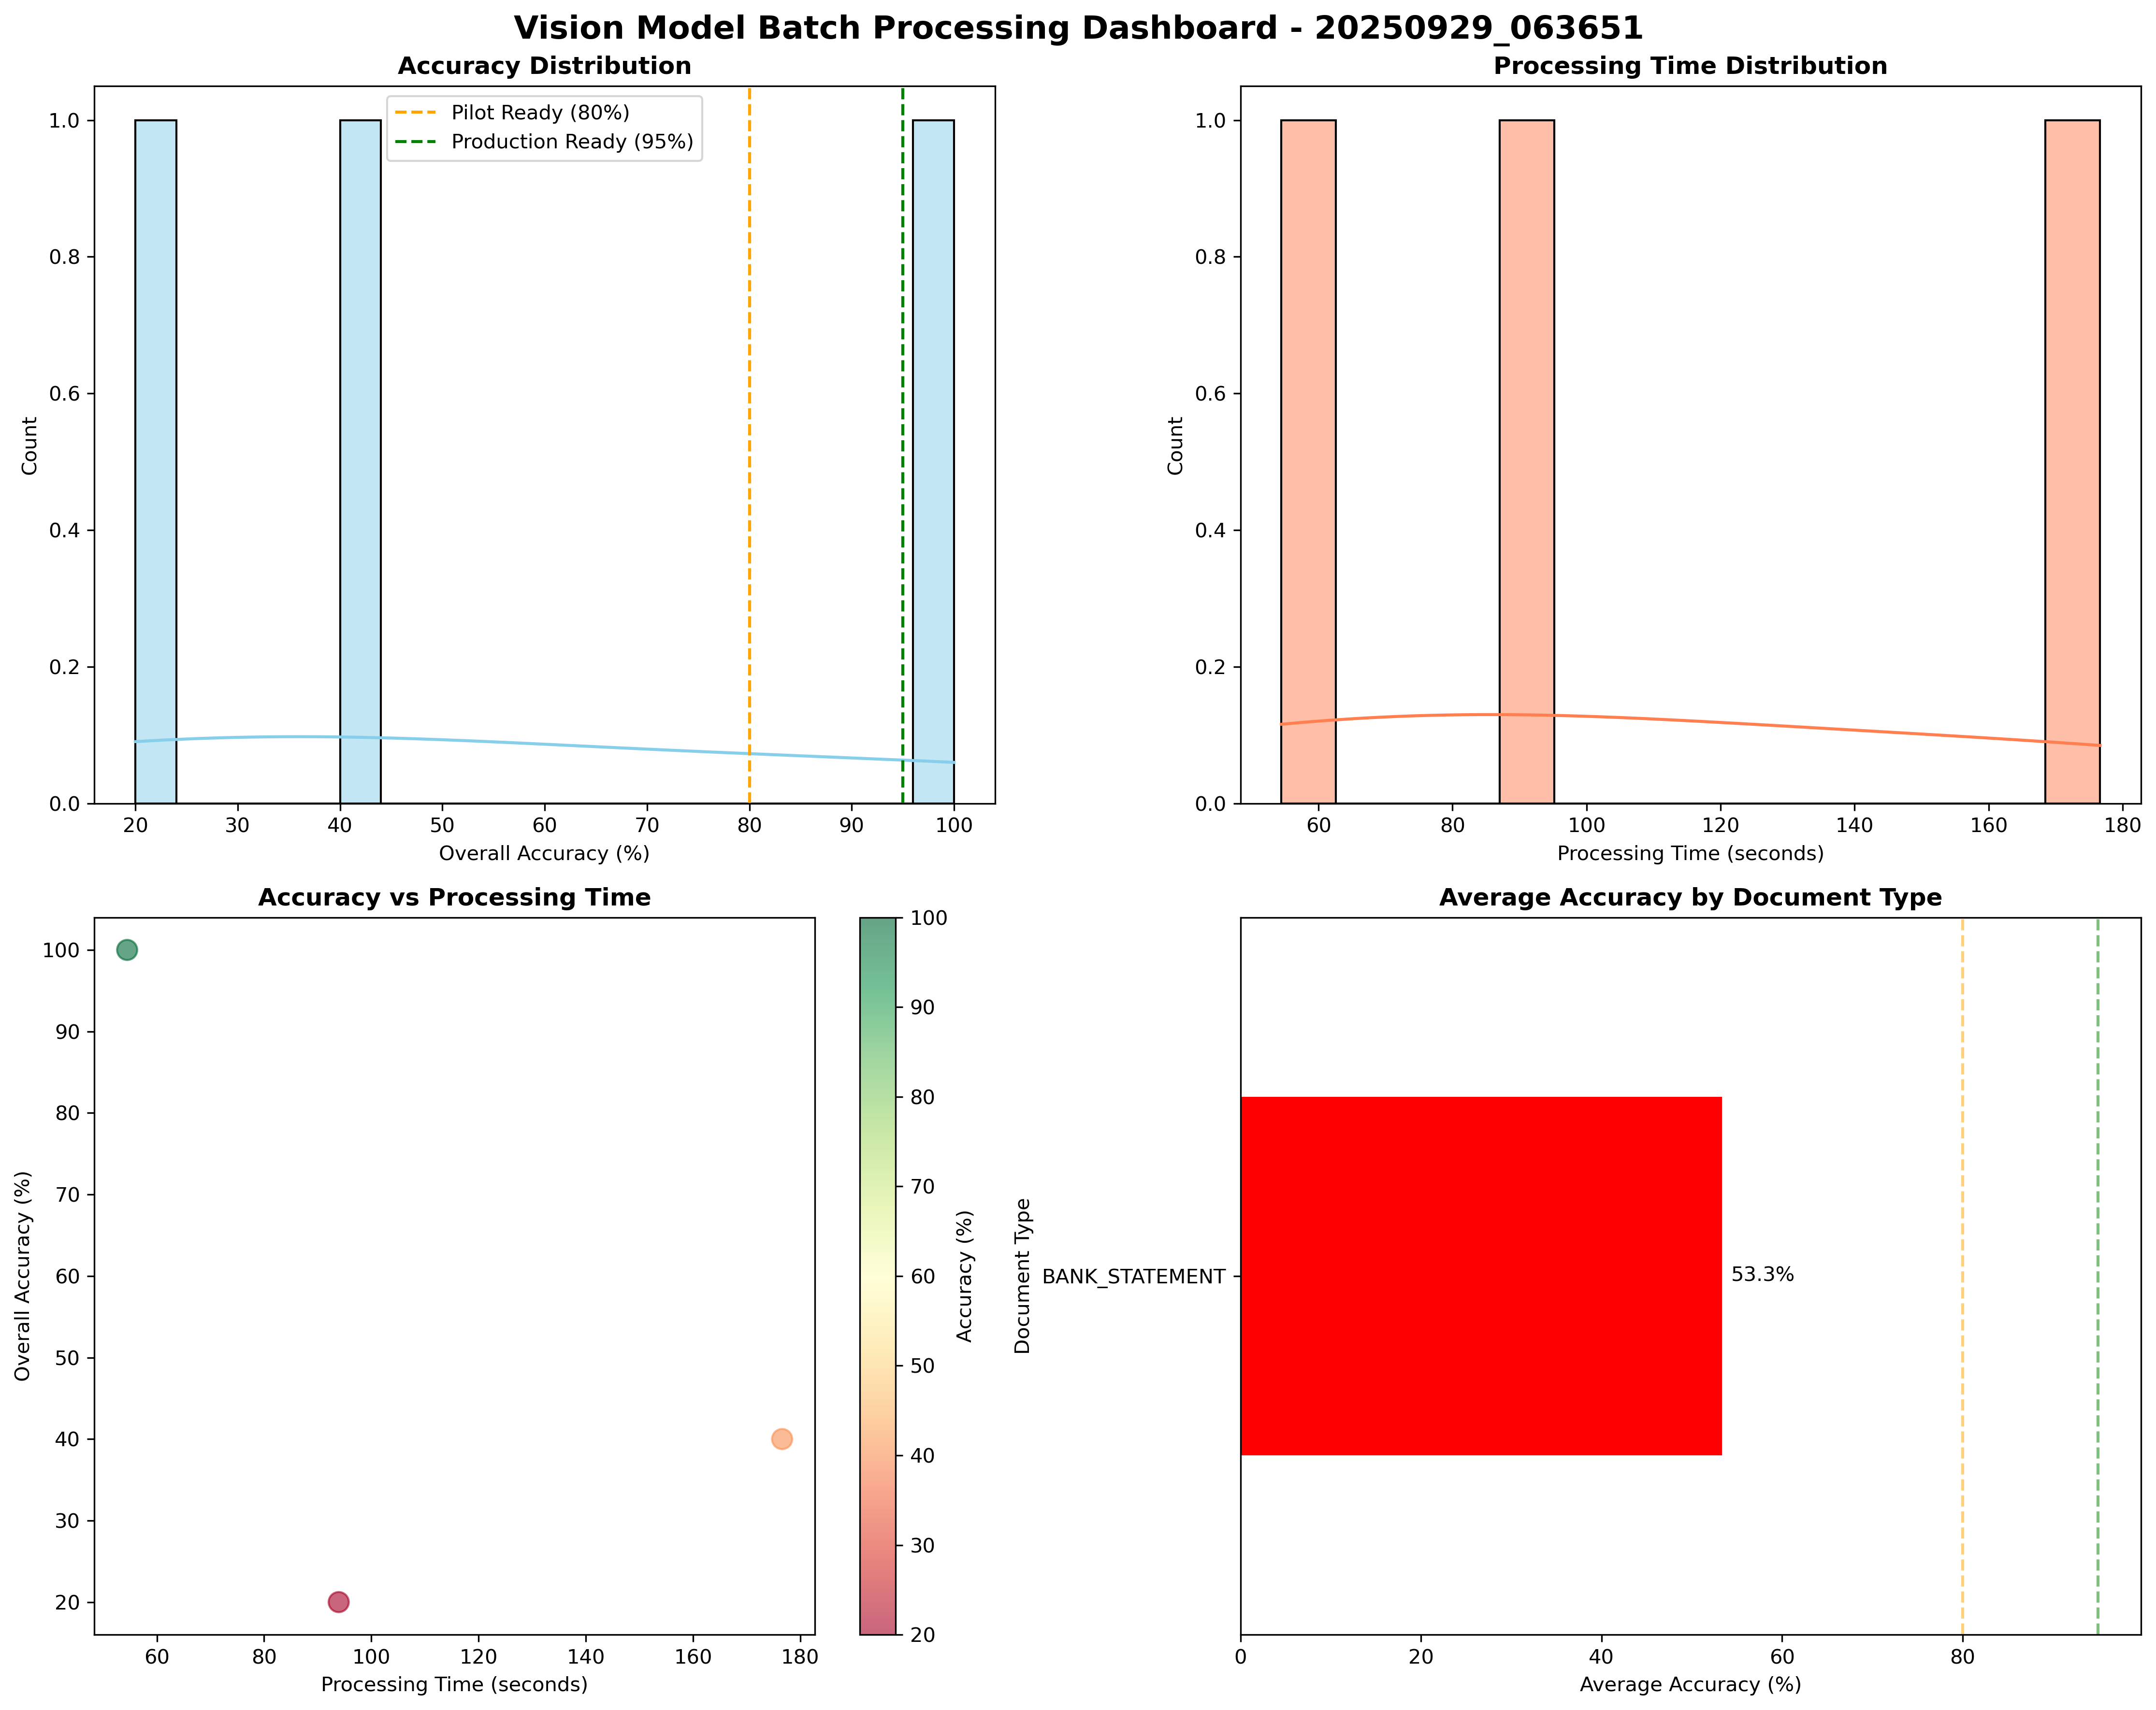

In [11]:
# Display final summary
console.rule("[bold green]InternVL3 Batch Processing Complete[/bold green]")

total_images = len(batch_results)
successful = len([r for r in batch_results if 'error' not in r])
avg_accuracy = df_results['overall_accuracy'].mean() if len(df_results) > 0 else 0

rprint(f"[bold green]✅ Processed: {total_images} images[/bold green]")
rprint(f"[cyan]Success Rate: {(successful/total_images*100):.1f}%[/cyan]")
rprint(f"[cyan]Average Accuracy: {avg_accuracy:.2f}%[/cyan]")
rprint(f"[cyan]Output: {OUTPUT_BASE}[/cyan]")

# Document type distribution
if document_types_found:
    rprint("\n[bold blue]📋 Document Type Distribution:[/bold blue]")
    for doc_type, count in document_types_found.items():
        percentage = (count / total_images * 100) if total_images > 0 else 0
        rprint(f"[cyan]  {doc_type}: {count} documents ({percentage:.1f}%)[/cyan]")

# Display dashboard if available
dashboard_files = list(OUTPUT_DIRS['visualizations'].glob(f"dashboard_{BATCH_TIMESTAMP}.png"))
if dashboard_files:
    from IPython.display import Image, display
    dashboard_path = dashboard_files[0]
    rprint("\n[bold blue]📊 Visual Dashboard:[/bold blue]")
    display(Image(str(dashboard_path)))
else:
    rprint(f"\n[yellow]⚠️ Dashboard not found in {OUTPUT_DIRS['visualizations']}[/yellow]")